# Visualizing Samples and Labels from SPARK Dataset

This notebook helps to inspect the SPARK dataset. You can see samples from the dataset, with the corresponding ground truth labels.

In [2]:
# import helper class
from utils import SPARKDataset , PyTorchSparkDataset
from matplotlib import pyplot as plt
import torchvision
from random import randint

c:\Users\alexa\AppData\Local\Programs\Python\Python38\lib\site-packages\skimage\io\manage_plugins.py:23: UserWarning: Your installed pillow version is < 8.1.2. Several security issues (CVE-2021-27921, CVE-2021-25290, CVE-2021-25291, CVE-2021-25293, and more) have been fixed in pillow 8.1.2 or higher. We recommend to upgrade this library.
  from .collection import imread_collection_wrapper
c:\Users\alexa\AppData\Local\Programs\Python\Python38\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Found Pytorch


In [3]:
# set up the path to a local copy of the SPARK dataset, labels csv files should be in the same directory.
dataset_root_dir='./data/' # dataset directory
split='train' #split: train,valid,test
total_images=9 # total number of images in the split
class_map= {'proba_2':0, 'cheops':1, 'debris':2, 'double_star':3, 'earth_observation_sat_1':4, 'lisa_pathfinder':5,
                           'proba_3_csc' :6, 'proba_3_ocs':7, 'smart_1':8, 'soho':9, 'xmm_newton':10} # Class map

dataset = SPARKDataset(class_map, root_dir=dataset_root_dir,split=split)

### Displaying random set of images

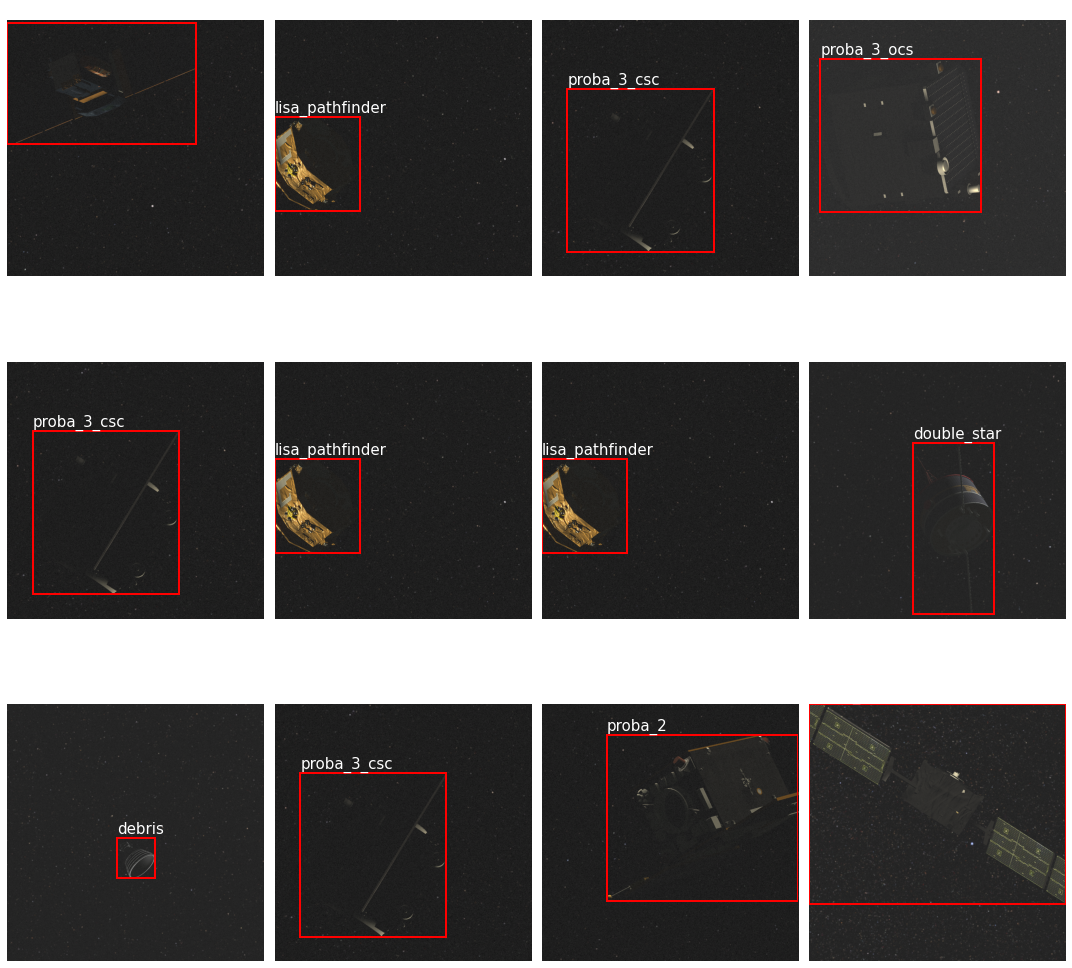

In [4]:
rows = 3
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

for i in range(rows):
    for j in range(cols):
        dataset.visualize(randint(0, total_images),size = (10,10),ax=axes[i][j])
        axes[i][j].axis('off')
fig.tight_layout() 

### Pytorch Dataset and Dataloader for SPARK

In [5]:
pytorch_dataset = PyTorchSparkDataset(class_map, root_dir=dataset_root_dir,split='train')

In [6]:
import torch
torch.cuda.empty_cache()
train_loader = torch.utils.data.DataLoader(pytorch_dataset, batch_size=10,drop_last=True)

for i,sample in enumerate(train_loader):
    print(f'image shape {sample[0].shape} labels shape {sample[1].shape} bounding box shape {sample[2].shape}')
    if i == 3:
        break

image shape torch.Size([10, 3, 1024, 1024]) labels shape torch.Size([10]) bounding box shape torch.Size([10, 4])


### Import dataset

In [7]:
import pandas as pd 
import os 
import numpy as np 
from PIL import Image

class satellite_dataset(torch.utils.data.Dataset):
    def __init__(self,root,folder='train',transforms=None):
        self.transforms=[]
        if transforms!=None:
            self.transforms.append(transforms)
        self.root=root
        self.folder=folder
        box_data=pd.read_csv(os.path.join(root, "train.csv"))
        # print(box_data)
        self.box_data=pd.concat([box_data,box_data.bbox.str.split('[').str.get(1).str.split(']').str.get(0).str.split(',',expand=True)],axis=1)
        self.imgs=list(os.listdir(os.path.join(root, self.folder)))
    def __len__(self):
        return len(self.imgs)
        
    def __getitem__(self,idx):
        img_path=os.path.join(os.path.join(self.root,self.folder),self.imgs[idx])
        img = Image.open(img_path).convert("RGB")
        df=self.box_data[self.box_data['filename']==self.imgs[idx]]
        #df=self.box_data[self.box_data['filename']==self.imgs[idx].split('.')[0]]
        # print(self.box_data['filename'])
        # print(self.imgs[idx].split('.')[0])
        # print(df)
        if df.shape[0]!=0:
            df[2]=df[0].astype(float)+df[2].astype(float)
            df[3]=df[1].astype(float)+df[3].astype(float)
            boxes=df[[0,1,2,3]].astype(float).values
            labels=np.ones(len(boxes))
        else:
            boxes=np.asarray([[0,0,0,0]])
            labels=np.ones(len(boxes))
        for i in self.transforms:
            img=i(img)
            
        targets={}
        targets['boxes']=torch.from_numpy(boxes).double()
        targets['labels']=torch.from_numpy(labels).type(torch.int64)
        #targets['id']=self.imgs[idx].split('.')[0]
        return img.double(),targets

root='C:\\Users\\alexa\\Desktop\\CVIA-Project\\2022-utils-main\\stream-1\\data'


dataset=satellite_dataset(root,'train',transforms=torchvision.transforms.ToTensor())

dataset[0]

<ipython-input-7-4e131934136a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[2]=df[0].astype(float)+df[2].astype(float)
<ipython-input-7-4e131934136a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[3]=df[1].astype(float)+df[3].astype(float)


(tensor([[[0.0824, 0.1412, 0.1059,  ..., 0.1529, 0.1294, 0.0510],
          [0.1216, 0.1412, 0.1412,  ..., 0.1529, 0.1294, 0.0510],
          [0.1059, 0.1059, 0.1373,  ..., 0.0510, 0.1529, 0.1529],
          ...,
          [0.1608, 0.1843, 0.1843,  ..., 0.1529, 0.0784, 0.1098],
          [0.1451, 0.0863, 0.1176,  ..., 0.0784, 0.1098, 0.1529],
          [0.1412, 0.1137, 0.1412,  ..., 0.1059, 0.1529, 0.1059]],
 
         [[0.0824, 0.1373, 0.1020,  ..., 0.1529, 0.1294, 0.0549],
          [0.1255, 0.1373, 0.1412,  ..., 0.1529, 0.1294, 0.0549],
          [0.1059, 0.1020, 0.1373,  ..., 0.0549, 0.1490, 0.1529],
          ...,
          [0.1608, 0.1843, 0.1804,  ..., 0.1529, 0.0706, 0.1020],
          [0.1451, 0.0863, 0.1176,  ..., 0.0706, 0.1020, 0.1569],
          [0.1451, 0.1137, 0.1451,  ..., 0.1020, 0.1529, 0.1020]],
 
         [[0.0824, 0.1373, 0.1059,  ..., 0.1529, 0.1294, 0.0510],
          [0.1255, 0.1412, 0.1412,  ..., 0.1529, 0.1255, 0.0510],
          [0.1059, 0.1059, 0.1373,  ...,

In [8]:
torch.manual_seed(1)
indices = torch.randperm(len(dataset)).tolist()
dataset_train = torch.utils.data.Subset(dataset, indices[:-10])
dataset_test = torch.utils.data.Subset(dataset, indices[-10:])
data_loader_train = torch.utils.data.DataLoader(dataset_train, batch_size=4, shuffle=True,collate_fn=lambda x:list(zip(*x)))
data_loader_test = torch.utils.data.DataLoader(dataset_test, batch_size=4, shuffle=False,collate_fn=lambda x:list(zip(*x)))

def collate_fn(batch):
    return tuple(zip(*batch))
val_dl = torch.utils.data.DataLoader(dataset_train, batch_size=8, collate_fn=collate_fn, pin_memory = True)

### Define Faster-RCNN model

In [9]:
# Imports
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Define model
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(petrained = True)

num_classes = 11

in_features = model.roi_heads.box_predictor.cls_score.in_features 

model.roi_heads.box_predictor = FastRCNNPredictor(in_features,num_classes)

model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01)

In [10]:
model.train()
from tqdm.notebook import tqdm
for epoch in tqdm(range(2)):
    for images,targets in tqdm(data_loader_train):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        model=model.double()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        losses.backward()

        optimizer.zero_grad()
        optimizer.step()
        
    print("Loss = {:.4f} ".format(losses.item()))

torch.save(model.state_dict(), './model.pth')

<ipython-input-7-4e131934136a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[2]=df[0].astype(float)+df[2].astype(float)
<ipython-input-7-4e131934136a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[3]=df[1].astype(float)+df[3].astype(float)



Loss = 3.1206 


<ipython-input-7-4e131934136a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[2]=df[0].astype(float)+df[2].astype(float)
<ipython-input-7-4e131934136a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[3]=df[1].astype(float)+df[3].astype(float)



Loss = 3.1169 



### idk what this is

<ipython-input-7-4e131934136a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[2]=df[0].astype(float)+df[2].astype(float)
<ipython-input-7-4e131934136a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[3]=df[1].astype(float)+df[3].astype(float)


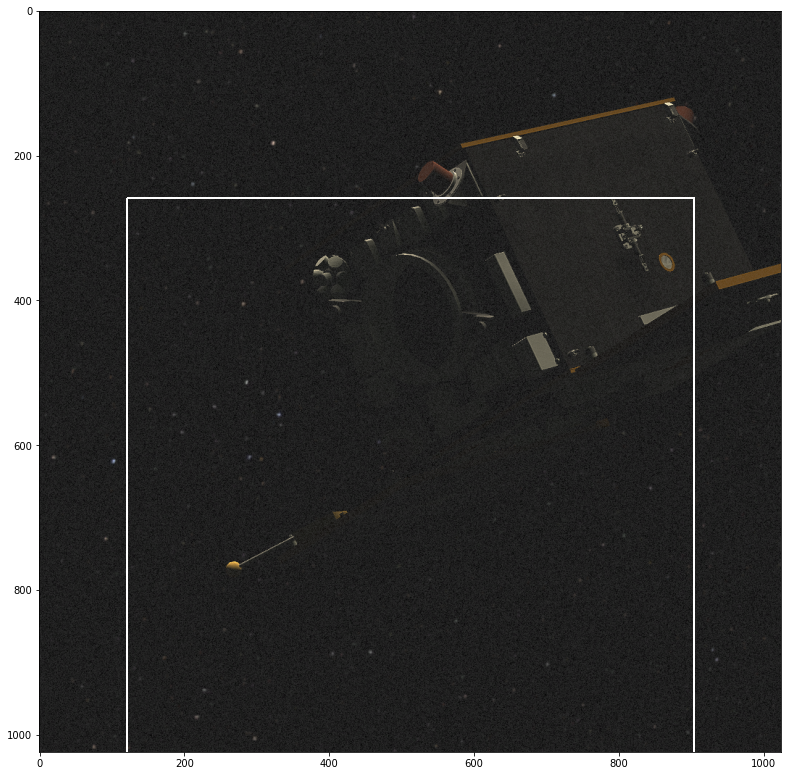

In [17]:
import numpy as np



torch.manual_seed(1)

images,labels=next(iter(data_loader_train))
from matplotlib import patches
def view(images,labels,k,std=1,mean=0):
    figure = plt.figure(figsize=(30,30))
    images=list(images)
    labels=list(labels)
    for i in range(k):
        out=torchvision.utils.make_grid(images[i])
        inp=out.cpu().numpy().transpose((1,2,0))
        inp=np.array(std)*inp+np.array(mean)
        inp=np.clip(inp,0,1)  
        ax = figure.add_subplot(2,2, i + 1)
        ax.imshow(images[i].cpu().numpy().transpose((1,2,0)))
        l=labels[i]['boxes'].cpu().numpy()
        l[:,2]=l[:,2]-l[:,0]
        l[:,3]=l[:,3]-l[:,1]
        for j in range(len(l)):
            ax.add_patch(patches.Rectangle((l[j][0],l[j][1]),l[j][2],l[j][3],linewidth=2,edgecolor='w',facecolor='none')) 

view(images,labels,1)

### Evaluate Model

In [21]:

images,targets=next(iter(data_loader_test))
images = list(image.to(device) for image in images)
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

model.eval()
output=model(images)

with torch.no_grad():
    view(images,output,2)



<ipython-input-7-4e131934136a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[2]=df[0].astype(float)+df[2].astype(float)
<ipython-input-7-4e131934136a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[3]=df[1].astype(float)+df[3].astype(float)
<ipython-input-7-4e131934136a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

OutOfMemoryError: CUDA out of memory. Tried to allocate 24.00 MiB (GPU 0; 8.00 GiB total capacity; 7.10 GiB already allocated; 0 bytes free; 7.26 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [14]:
import torchvision.transforms as T
from PIL import Image, ImageDraw
dict = output[0]
results=[]

for images, targets, idx in val_dl:    

    images = list(image.to(device) for image in images)
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    outputs = model(images)

    for i, image in enumerate(images):

        boxes = outputs[i]['boxes'].data
        scores = outputs[i]['scores'].data
        labels = outputs[i]['labels'].data

        keep = torchvision.ops.nms(boxes, scores, 0.3)
        boxes = boxes[keep]
        scores = scores[keep]
        image_id = idx[i]
    
        op = (idx[i], boxes, scores)
        results.append(op)

        break
    break

im_name = image_id + '.jpg'
img = Image.open(root/'train'/im_name).convert("RGB")
img = T.ToTensor()(img)

# make a function to prepare and annotate images
im = (img.permute(1,2,0).detach().numpy() * 255).astype('uint8')
vsample = Image.fromarray(im)

draw = ImageDraw.Draw(vsample)
for box in boxes:
    draw.rectangle(list(box), fill = None, outline = "red")
vsample

<ipython-input-7-4e131934136a>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[2]=df[0].astype(float)+df[2].astype(float)
<ipython-input-7-4e131934136a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[3]=df[1].astype(float)+df[3].astype(float)


ValueError: not enough values to unpack (expected 3, got 2)